# 04 · All features + ablation (Step 5)

**Goal:** measure what each history table adds. LightGBM (same settings as v0 in Step 4) is trained
on the same 5 folds, adding one data source at a time:
main → + bureau → + previous applications → + installments → + POS/cash → + credit cards.

The last row (all seven tables) is **LightGBM v1**. On the real data this notebook takes about
8–12 minutes. Results go to `reports/results_step5_ablation.csv`,
`reports/figures/fig12_ablation.png`, `reports/figures/fig13_top_features.png` and MLflow.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.evaluation.bootstrap import paired_bootstrap
from creditrisk.evaluation.cv import run_cv
from creditrisk.features.build import PREFIXES, load_features
from creditrisk.models import baselines
from creditrisk.models.data import get_xy

SEED = set_seed()
FIG = get_path("figures")
facts = {}

features = load_features()
splits = load_splits()
X_all, y, folds, ids = get_xy(features, splits, "train")


def table_of(col: str) -> str:
    return next(p.rstrip("_") for p in PREFIXES if col.startswith(p))


per_table = pd.Series([table_of(c) for c in X_all.columns]).value_counts().reindex(
    [p.rstrip("_") for p in PREFIXES])
print(f"train split: {X_all.shape[0]:,} rows x {X_all.shape[1]} features")
display(per_table.rename("features").to_frame().T)

train split: 184,503 rows x 240 features


,APP,BUR,BB,PREV,INST,POS,CC
features,120,31,9,32,22,12,14


## Ablation: add one data source at a time
Every run uses the same folds and the same LightGBM settings, so the only thing that changes
is the set of columns. `BB_` (bureau_balance) is added together with `BUR_` (bureau).

In [2]:
steps = [
    ("main table", ["APP_"]),
    ("+ bureau", ["APP_", "BUR_", "BB_"]),
    ("+ previous", ["APP_", "BUR_", "BB_", "PREV_"]),
    ("+ installments", ["APP_", "BUR_", "BB_", "PREV_", "INST_"]),
    ("+ POS/cash", ["APP_", "BUR_", "BB_", "PREV_", "INST_", "POS_"]),
    ("+ credit cards (all = v1)", PREFIXES),
]
ablation = {}
for i, (label, prefixes) in enumerate(steps):
    cols = [c for c in X_all.columns if c.startswith(tuple(prefixes))]
    result = run_cv(lambda: baselines.lightgbm(seed=SEED), X_all[cols], y, folds,
                    name=f"step5_ablation_{i}", ids=ids, step=5)
    ablation[label] = (len(cols), result)
    s = result.summary
    print(f"{label:<27} {len(cols):>4} features  ROC-AUC {s['roc_auc']:.4f} "
          f"[{s['roc_auc_low']:.4f}, {s['roc_auc_high']:.4f}]  ({s['seconds']:.0f}s)")

/home/amartya/Desktop/prmlproject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


main table                   120 features  ROC-AUC 0.7612 [0.7578, 0.7646]  (45s)
+ bureau                     160 features  ROC-AUC 0.7709 [0.7673, 0.7741]  (49s)
+ previous                   192 features  ROC-AUC 0.7764 [0.7728, 0.7797]  (61s)
+ installments               214 features  ROC-AUC 0.7816 [0.7781, 0.7848]  (64s)
+ POS/cash                   226 features  ROC-AUC 0.7838 [0.7802, 0.7871]  (75s)
+ credit cards (all = v1)    240 features  ROC-AUC 0.7860 [0.7826, 0.7895]  (77s)


## Ablation table
The gain of each step is tested against the step before it (paired bootstrap).

In [3]:
rows, previous = [], None
for label, (n_cols, result) in ablation.items():
    row = {"step": label, "features": n_cols,
           "ROC-AUC": round(result.summary["roc_auc"], 4),
           "95% CI": f"{result.summary['roc_auc_low']:.4f} to {result.summary['roc_auc_high']:.4f}"}
    if previous is not None:
        d = paired_bootstrap(y, result.oof, previous.oof, n_boot=300)
        row.update({"gain": round(d["difference"], 4),
                    "gain 95% CI": f"{d['low']:+.4f} to {d['high']:+.4f}",
                    "significant": d["significant"]})
    rows.append(row)
    previous = result
ablation_table = pd.DataFrame(rows).set_index("step")
ablation_table.to_csv(PROJECT_ROOT / "reports" / "results_step5_ablation.csv")
display(ablation_table)
print("saved reports/results_step5_ablation.csv")

first, last = list(ablation.values())[0][1], list(ablation.values())[-1][1]
facts["auc_main_table"] = round(first.summary["roc_auc"], 4)
facts["auc_all_tables_v1"] = round(last.summary["roc_auc"], 4)
facts["v1_ci"] = (round(last.summary["roc_auc_low"], 4), round(last.summary["roc_auc_high"], 4))
facts["total_gain"] = round(last.summary["roc_auc"] - first.summary["roc_auc"], 4)
facts["gain_per_step"] = ablation_table["gain"].dropna().to_dict()

,features,ROC-AUC,95% CI,gain,gain 95% CI,significant
step,,,,,,
main table,120,0.7612,0.7578 to 0.7646,NaN,NaN,NaN
+ bureau,160,0.7709,0.7673 to 0.7741,0.0097,+0.0079 to +0.0111,True
+ previous,192,0.7764,0.7728 to 0.7797,0.0055,+0.0040 to +0.0070,True
+ installments,214,0.7816,0.7781 to 0.7848,0.0053,+0.0039 to +0.0067,True
+ POS/cash,226,0.7838,0.7802 to 0.7871,0.0021,+0.0009 to +0.0032,True
+ credit cards (all = v1),240,0.7860,0.7826 to 0.7895,0.0022,+0.0010 to +0.0036,True


saved reports/results_step5_ablation.csv


saved reports/figures/fig12_ablation.png


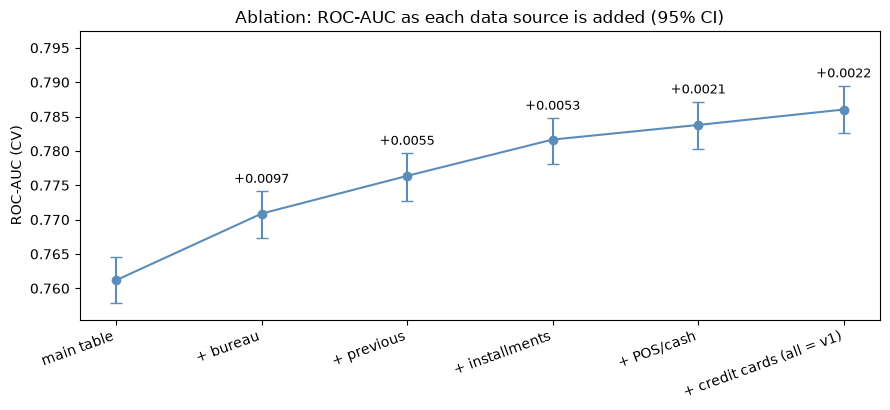

In [4]:
labels = list(ablation)
aucs = np.array([r.summary["roc_auc"] for _, r in ablation.values()])
lows = np.array([r.summary["roc_auc_low"] for _, r in ablation.values()])
highs = np.array([r.summary["roc_auc_high"] for _, r in ablation.values()])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.errorbar(range(len(labels)), aucs, yerr=[aucs - lows, highs - aucs], fmt="o-", capsize=4,
            color="#5B8DB8")
for i in range(1, len(labels)):
    ax.annotate(f"{aucs[i] - aucs[i - 1]:+.4f}", (i, highs[i]), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=9)
margin = 0.25 * (highs.max() - lows.min())
ax.set_ylim(lows.min() - 0.3 * margin, highs.max() + margin)  # room for the gain labels
ax.set_xticks(range(len(labels)), labels, rotation=20, ha="right")
ax.set(title="Ablation: ROC-AUC as each data source is added (95% CI)", ylabel="ROC-AUC (CV)")
fig.tight_layout()
fig.savefig(FIG / "fig12_ablation.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/fig12_ablation.png")

## Which features does LightGBM v1 use most?
A quick look with LightGBM's *gain* importance, from one model trained on the whole train split.
Gain importance is biased toward continuous features; the proper explanations (SHAP, including
SHAP per table) come in Step 12.

,APP,PREV,BUR,INST,CC,POS,BB
% of total gain,59.7,12.8,12.2,7.3,4.0,2.9,1.1


saved reports/figures/fig13_top_features.png


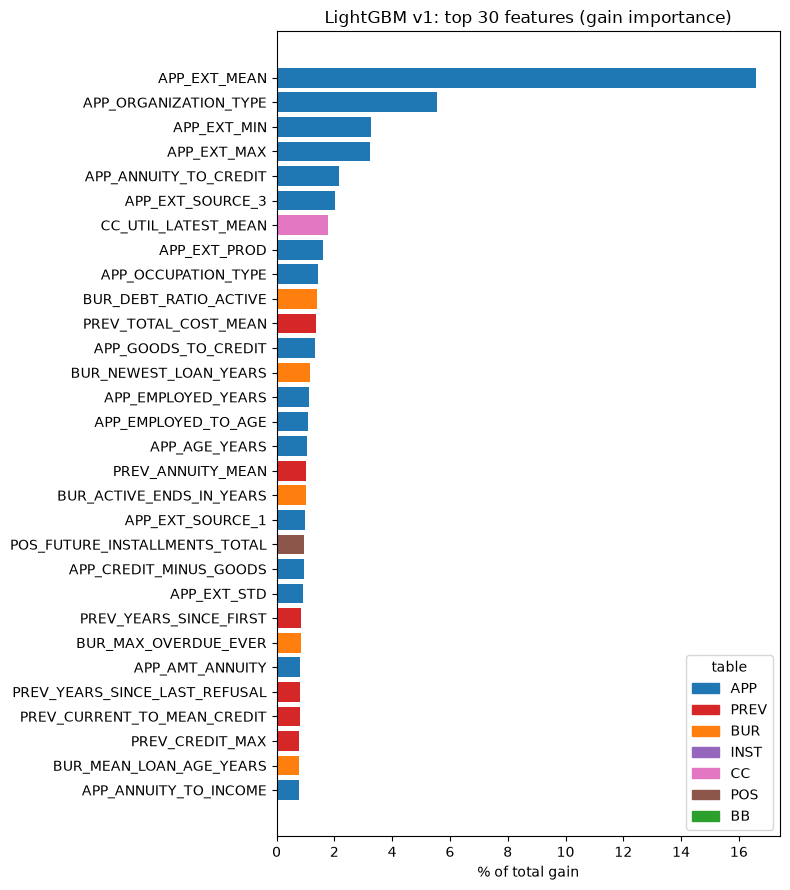

In [5]:
model = baselines.lightgbm(seed=SEED).fit(X_all, y)
gain = pd.Series(model.booster_.feature_importance(importance_type="gain"),
                 index=model.booster_.feature_name()).sort_values(ascending=False)
share_by_table = (gain.groupby(gain.index.map(table_of)).sum() / gain.sum()).sort_values(
    ascending=False)
facts["gain_share_by_table_%"] = (100 * share_by_table).round(1).to_dict()
facts["top_5_features"] = list(gain.index[:5])
display((100 * share_by_table).round(1).rename("% of total gain").to_frame().T)

colors = dict(zip([p.rstrip("_") for p in PREFIXES], plt.cm.tab10.colors, strict=False))
top = gain.head(30)[::-1]
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(top.index, top.values / gain.sum() * 100, color=[colors[table_of(c)] for c in top.index])
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in share_by_table.index]
ax.legend(handles, share_by_table.index, title="table", loc="lower right")
ax.set(title="LightGBM v1: top 30 features (gain importance)", xlabel="% of total gain")
fig.tight_layout()
fig.savefig(FIG / "fig13_top_features.png", dpi=150, bbox_inches="tight")
print("saved reports/figures/fig13_top_features.png")

## Key facts
Copy these numbers into your Findings below.

In [6]:
for key, value in facts.items():
    print(f"{key:<26} {value}")

auc_main_table             0.7612
auc_all_tables_v1          0.786
v1_ci                      (0.7826, 0.7895)
total_gain                 0.0248
gain_per_step              {'+ bureau': 0.0097, '+ previous': 0.0055, '+ installments': 0.0053, '+ POS/cash': 0.0021, '+ credit cards (all = v1)': 0.0022}
gain_share_by_table_%      {'APP': 59.7, 'PREV': 12.8, 'BUR': 12.2, 'INST': 7.3, 'CC': 4.0, 'POS': 2.9, 'BB': 1.1}
top_5_features             ['APP_EXT_MEAN', 'APP_ORGANIZATION_TYPE', 'APP_EXT_MIN', 'APP_EXT_MAX', 'APP_ANNUITY_TO_CREDIT']


The feature table has 241 features: application 121, bureau 31, bureau_balance 9, previous applications 32, installments 22, POS/cash 12, credit cards 14. 240 are model inputs; gender is kept only for fairness checks.
Main table only: ROC-AUC 0.7612, the same setup as LightGBM v0 in Step 4.
+ bureau (with bureau_balance): 0.7709 (gain +0.0097, significant: Yes), the biggest single gain.
+ previous applications: 0.7764 (gain +0.0055, significant: Yes).
+ installments: 0.7817 (gain +0.0053, significant: Yes).
+ POS/cash: 0.7838 (gain +0.0021, significant: Yes).
+ credit cards = LightGBM v1 (all 7 tables): 0.7860 (gain +0.0022, significant: Yes), 95% CI 0.7826 to 0.7895.
In total, the six history tables add +0.0248 ROC-AUC. The confidence intervals of v0 (0.758–0.765) and v1 (0.783–0.790) don't overlap, so the overall gain is clearly real.
Diminishing returns: each new table adds less than the one before. POS/cash and credit cards add only about +0.002 each, because they mostly repeat what bureau and installments already show, and credit cards reach only 28% of applicants.
Gain importance: the application table still gives 59.7% of the total gain, then previous applications (12.8%), bureau (12.2%), installments (7.3%), credit cards (4.0%), POS (2.9%) and bureau_balance (1.1%). bureau_balance covers only 30% of applicants and adds little, exactly as the EDA predicted.
Top 5 features: EXT_MEAN, ORGANIZATION_TYPE, EXT_MIN, EXT_MAX, ANNUITY_TO_CREDIT. Four of the five are features we engineered.
Gain importance is a quick, biased view; proper SHAP explanations come in Step 12.